# Branch-whorl detection in TLS point clouds — minimal Colab reproduction

Reproduction of the inference pipeline of:

**Pehkonen, M. et al. (2025). "Identification and segmentation of branch whorls and sawlogs in standing timber using terrestrial laser scanning and deep learning." *Forestry*, cpaf006.** [doi:10.1093/forestry/cpaf006](https://doi.org/10.1093/forestry/cpaf006)

Author implementation (pinned): [`MikaPehkonenHelsinki/Sawlog-branch-whorl-detector`](https://github.com/MikaPehkonenHelsinki/Sawlog-branch-whorl-detector) @ commit `db6ded8d8ebae78859b21441ec25f1d69d793b38` (README.md; `whorlDetect-improved.py`; `whorlDetect.ipynb`).

**Scope — partial, inference-only demonstration.** This notebook reproduces the paper's *whorl-detector inference subsection* on **one example tree** (`1022.las`, 30 MB): it crops the example point cloud to each sawlog partition listed for that tree, renders the partition in the four view directions used by the authors, runs the authors' pre-trained YOLOv5x whorl detector (`whorlDetector.pt`), clusters detections across directions, and writes per-log `whorl_count` and `mean_whorl_distance` to `whorls.csv` — exactly the repo's documented pipeline. Training (506 annotated images, 300 epochs), the sawlog detector, and the 479-tree/X-ray evaluation are **out of scope** (those data are only available on request, per the paper's data-availability statement).

**ADAPTED PYTHON DEMONSTRATION — AI-assisted adaptation.** The authors did not provide this Colab implementation. Their renderer uses an Open3D `Visualizer` OpenGL window, which cannot open on a headless Colab runtime, so the rendering step is re-implemented here as an equivalent orthographic point rasterization (same cropped points, same four camera directions `front = (0,1,0), (-1,0,0), (0,-1,0), (1,0,0)` with up `+z`, white points on black background, content-bounding-box crop, square points like Open3D's `point_size`). The detector call and all clustering/metric formulas are used exactly as written by the authors. The executed example and listed checks were validated, but untested behaviour is not guaranteed.

**日本語要約:** このノートブックは、地上レーザースキャン点群から丸太(sawlog)区間を四面方向にレンダリングし、著者公開済みの YOLOv5x「節(whorl)検出モデル」で節を検出し、方向間の検出を線形クラスタリングで統合して `whorls.csv`（節数・平均節間隔）を出力する、論文の推論パイプラインの最小再現です。著者の Open3D ウィンドウ描画はヘッドレスな Colab で実行できないため、同一の射影・視線方向・白色点/黒背景を再現する numpy ラスタライズ描画に**適応**しています（AI による翻訳実装であり、著者提供の Colab 実装ではありません）。学習・丸太検出器・479 本評価は対象外です。

In [ ]:
import platform, sys, os
print("Python:", sys.version.split()[0], "|", platform.machine())
try:
    import torch
    print("torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
except ImportError:
    print("torch: not preinstalled (it is installed with the yolov5 requirements below)")
print("Recommended runtime: CPU (this minimal demo needs no GPU; a T4 also works)")
print("Working directory:", os.getcwd())

Python: 3.13.16 | x86_64


torch: 2.11.0+cpu | CUDA available: False
Recommended runtime: CPU (this minimal demo needs no GPU; a T4 also works)
Working directory: /content


## Runtime selection and Run all

**Runtime → Change runtime type → CPU** is sufficient and recommended for this demo (YOLOv5x CPU inference on a handful of images takes seconds each). A T4 GPU runtime also runs the same notebook unchanged — the detector picks up CUDA automatically if present.

**Run all** end to end takes roughly **5–10 minutes**: ~2–4 min dependency setup (yolov5 clone + requirements), ~30 MB point-cloud + ~165 MB model download, seconds per rendered image of detection.

**Downloads in this notebook** (all pinned to author commit `db6ded8`):
`point_clouds/1022.las` (30,000,375 bytes), `tree_log_locations.xlsx` (9,170 bytes), `whorlDetector.pt` (Git LFS object, 173,031,937 bytes, sha256 `f659f6c8…`), plus the authors' shipped reference render/detections for tree 1022 log 2 used for comparison in §7.

**日本語:** ランタイムは **CPU で十分**です（GPU でもそのまま動作します）。Run all で約 5〜10 分、ダウンロードは合計約 200 MB（点群 30 MB + モデル 165 MB 等）です。

## 1. Dependencies

The authors' notebook installs `open3d`, `laspy`, `pillow` and then clones **ultralytics/yolov5** and installs its requirements. We keep the same route; `open3d` is not needed here because rendering is adapted (see §4), but `laspy` (point-cloud I/O), `openpyxl` (reading the authors' `tree_log_locations.xlsx`) and the pinned yolov5 checkout are required. yolov5 is pinned to master commit `f9578796b8a64889aa9e66dc06914d19f40d338e` (2026-10-06) for reproducibility; the authors clone the default branch.

**日本語:** 著者のノートブックと同じ経路（yolov5 の clone + requirements）で依存関係を整えます。描画の適応のため `open3d` は不要です。再現性のため yolov5 はコミットに固定します。

In [ ]:
import os, subprocess, sys

WORK = os.getcwd()  # notebook root under /content in Colab

print("Installing laspy / openpyxl ...")
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "laspy", "openpyxl"], check=True)

YOLOV5_COMMIT = "f9578796b8a64889aa9e66dc06914d19f40d338e"  # ultralytics/yolov5 master, 2026-10-06
if not os.path.isdir("yolov5"):
    print("Cloning ultralytics/yolov5 (partial clone) ...")
    subprocess.run(["git", "clone", "--quiet", "--filter=blob:none",
                    "https://github.com/ultralytics/yolov5", "yolov5"], check=True)
print("Checking out pinned yolov5 commit ...")
subprocess.run(["git", "-C", "yolov5", "checkout", "--quiet", YOLOV5_COMMIT], check=True)
head = subprocess.run(["git", "-C", "yolov5", "rev-parse", "HEAD"],
                      check=True, capture_output=True, text=True).stdout.strip()
assert head == YOLOV5_COMMIT, f"yolov5 checkout mismatch: {head}"
print("Installing yolov5 requirements ...")
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "yolov5/requirements.txt"],
               check=True)
print("Dependencies ready. WORK =", WORK)

Installing laspy / openpyxl ...


Cloning ultralytics/yolov5 (partial clone) ...


Checking out pinned yolov5 commit ...
Installing yolov5 requirements ...


Dependencies ready. WORK = /content


## 2. Input acquisition (author repo, pinned commit)

All bytes are downloaded **inside this Colab runtime** from the pinned author commit. Per-file validation:

- `point_clouds/1022.las` — example terrestrial laser scanning point cloud of tree 1022; expected 30,000,375 bytes (plain Git blob).
- `tree_log_locations.xlsx` — the authors' table of tree stem XY positions and sawlog bottom/top heights; expected 9,170 bytes. Its per-row values are the measured inputs of the pipeline.
- `whorlDetector.pt` — the authors' trained YOLOv5x whorl detector. In the Git repository it is stored as **Git LFS** (pointer sha256 `f659f6c8c475d23701d87b3222ff6695d481591e91662dc82d54db933b0c2a7b`, payload 173,031,937 bytes). We fetch the payload and verify size, SHA-256, and the ZIP magic of a torch checkpoint (a 134-byte LFS pointer text file is rejected).
- Reference example outputs shipped by the authors for tree 1022 log 2 (`TLSimages/1022_2/*.png`, `detections/run/1022_2_*.png` and YOLO label `.txt` files) — used in §7 to compare our run against the authors' own example.

**日本語:** 全ての入力は Colab 内で、コミット固定の著者リポジトリ URL からダウンロードします。モデルは Git LFS 実体（173,031,937 バイト、SHA-256 検証付き）で、ポインタファイルであってはなりません。§7 の比較のため、著者が同梱する例（tree 1022, log 2 の描画・検出結果・ラベル）も取得します。

In [ ]:
import hashlib
import urllib.request
from pathlib import Path

COMMIT = "db6ded8d8ebae78859b21441ec25f1d69d793b38"
REPO = "MikaPehkonenHelsinki/Sawlog-branch-whorl-detector"
RAW = f"https://raw.githubusercontent.com/{REPO}/{COMMIT}"
MEDIA = f"https://media.githubusercontent.com/media/{REPO}/{COMMIT}"

def download(url, dest, timeout=180):
    dest = Path(dest)
    dest.parent.mkdir(parents=True, exist_ok=True)
    with urllib.request.urlopen(url, timeout=timeout) as r, open(dest, "wb") as f:
        f.write(r.read())
    return dest

def sha256_of(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

# --- example point cloud (plain git blob, size pinned from the repo metadata) ---
las_path = download(f"{RAW}/point_clouds/1022.las", "point_clouds/1022.las")
assert las_path.stat().st_size == 30_000_375, las_path.stat().st_size
print(f"OK point_clouds/1022.las ({las_path.stat().st_size:,} bytes)")

# --- measured input table ---
xlsx_path = download(f"{RAW}/tree_log_locations.xlsx", "tree_log_locations.xlsx")
assert xlsx_path.stat().st_size == 9_170, xlsx_path.stat().st_size
print(f"OK tree_log_locations.xlsx ({xlsx_path.stat().st_size:,} bytes)")

# --- trained model: LFS object; reject the pointer text, then verify hash ---
PT_SHA256 = "f659f6c8c475d23701d87b3222ff6695d481591e91662dc82d54db933b0c2a7b"
PT_SIZE = 173_031_937
pt = Path("whorlDetector.pt")
if not (pt.exists() and pt.stat().st_size == PT_SIZE):
    download(f"{RAW}/whorlDetector.pt", pt)
if pt.stat().st_size < 1_000_000:  # the LFS pointer text is ~134 bytes
    print("raw URL returned a Git LFS pointer; fetching the LFS payload from the media URL ...")
    download(f"{MEDIA}/whorlDetector.pt", pt)
assert pt.stat().st_size == PT_SIZE, f"whorlDetector.pt size {pt.stat().st_size}"
assert pt.read_bytes()[:2] == b"PK", "whorlDetector.pt is not a torch zip checkpoint"
assert sha256_of(pt) == PT_SHA256, "whorlDetector.pt sha256 mismatch"
print(f"OK whorlDetector.pt verified (sha256 {PT_SHA256[:12]}..., {PT_SIZE:,} bytes)")

# --- authors' shipped reference example for tree 1022 log 2 (comparison in §7) ---
from PIL import Image
REFERENCE_FILES = [
    "TLSimages/1022_2/1022_2_1.png", "TLSimages/1022_2/1022_2_2.png",
    "TLSimages/1022_2/1022_2_3.png", "TLSimages/1022_2/1022_2_4.png",
    "detections/run/1022_2_1.png", "detections/run/1022_2_2.png",
    "detections/run/1022_2_3.png", "detections/run/1022_2_4.png",
    "detections/run/labels/1022_2_1.txt", "detections/run/labels/1022_2_2.txt",
    "detections/run/labels/1022_2_3.txt", "detections/run/labels/1022_2_4.txt",
]
for name in REFERENCE_FILES:
    dest = download(f"{RAW}/{name}", Path("reference") / Path(name).name)
    if dest.suffix == ".png":
        with Image.open(dest) as im:
            im.verify()  # reject error pages saved as .png
        print(f"OK reference {dest.name} ({dest.stat().st_size:,} bytes, valid PNG)")
    else:
        n_lines = len(dest.read_text().strip().splitlines())
        print(f"OK reference {dest.name} ({n_lines} YOLO detections)")
print("All inputs acquired and validated.")

OK point_clouds/1022.las (30,000,375 bytes)
OK tree_log_locations.xlsx (9,170 bytes)


raw URL returned a Git LFS pointer; fetching the LFS payload from the media URL ...


OK whorlDetector.pt verified (sha256 f659f6c8c475..., 173,031,937 bytes)


OK reference 1022_2_1.png (21,231 bytes, valid PNG)
OK reference 1022_2_2.png (20,145 bytes, valid PNG)


OK reference 1022_2_3.png (20,976 bytes, valid PNG)
OK reference 1022_2_4.png (20,809 bytes, valid PNG)


OK reference 1022_2_1.png (201,055 bytes, valid PNG)


OK reference 1022_2_2.png (198,702 bytes, valid PNG)
OK reference 1022_2_3.png (193,369 bytes, valid PNG)


OK reference 1022_2_4.png (241,251 bytes, valid PNG)
OK reference 1022_2_1.txt (15 YOLO detections)


OK reference 1022_2_2.txt (13 YOLO detections)
OK reference 1022_2_3.txt (13 YOLO detections)


OK reference 1022_2_4.txt (20 YOLO detections)
All inputs acquired and validated.


## 3. Measured input table and example point cloud

`tree_log_locations.xlsx` drives the pipeline: each row names a tree and a sawlog partition with `log_bottom_h` / `log_top_h` (heights along the stem, metres) and the stem position `tree_X` / `tree_Y` inside the point cloud. We process only **tree 1022**, whose 30 MB example point cloud ships with the repository (the full 479-tree dataset is available from the authors on request only). This is the smallest scientifically valid sample: one tree, all of its listed sawlog partitions.

**日本語:** `tree_log_locations.xlsx` は各区間の高さと幹位置を与える計測入力テーブルです。ここでは同梱例の **tree 1022** のみを処理します（最小例）。まずテーブルを読み、tree 1022 の行を表示します。

In [ ]:
import pandas as pd

tree_locations = pd.read_excel("tree_log_locations.xlsx")
print("All columns:", list(tree_locations.columns))
print("Total rows:", len(tree_locations))
tree_id = 1022  # the example tree whose point cloud ships with the repo
logs = tree_locations[tree_locations["tree"] == tree_id].copy()
logs["log"] = logs["log"].astype(int)
print(f"\nRows for tree {tree_id}: {len(logs)}")
print(logs[["tree", "log", "log_bottom_h", "log_top_h", "tree_X", "tree_Y"]].to_string(index=False))

All columns: ['tree', 'tree_X', 'tree_Y', 'log', 'log_bottom_h', 'log_top_h']
Total rows: 3

Rows for tree 1022: 1
 tree  log  log_bottom_h  log_top_h    tree_X   tree_Y
 1022    2      3.910355   8.791355 -2.340104 0.275019


Point-cloud inspection before rendering: point count, height (z) range and spatial extent of `1022.las`. Heights in the table are metres above ground in the same coordinate system as the point cloud.

**日本語:** 描画前に `1022.las` の点数・z 範囲・水平範囲を確認します。

In [ ]:
import laspy
import numpy as np

las = laspy.read("point_clouds/1022.las")
pts = np.stack([las.x, las.y, las.z], axis=1)
print("Points:", f"{len(pts):,}")
print(f"z range: {pts[:,2].min():.2f} .. {pts[:,2].max():.2f} m")
print(f"x range: {pts[:,0].min():.2f} .. {pts[:,0].max():.2f} m")
print(f"y range: {pts[:,1].min():.2f} .. {pts[:,1].max():.2f} m")

Points: 1,000,000
z range: -1.48 .. 23.32 m
x range: -4.70 .. 0.20 m
y range: -2.20 .. 2.70 m


## 4. Sawlog-partition rendering — ADAPTED (numpy rasterization instead of Open3D)

The authors crop the cloud to each log (`log_bottom_h ≤ z ≤ log_top_h`, points within ±1 m of the stem XY — their `middle_dist = 1` in `whorlDetect-improved.py`) and capture an OpenGL screenshot of the partition in four directions with white points on a black background, then crop away the black margins. Because an Open3D `Visualizer` needs a display/GL context that a headless Colab runtime cannot provide, we rasterize the **same cropped points with the same four camera directions** ourselves:

| Author (Open3D, `whorlDetect-improved.py` lines 64–107) | This notebook |
| --- | --- |
| window 2000×3000, `point_size 5` square points | square points of `POINT_PX` pixels at `PX_PER_M` px/m |
| `set_front((0,1,0))`, `(-1,0,0)`, `(0,-1,0)`, `(1,0,0)`; `set_up((0,0,1))` | identical right-vector mapping (`front × up`): screen-right = +x, +y, −x, −y; screen-up = +z |
| white points, black background, content-bbox crop | identical |

The output images keep the authors' naming: `TLSimages/<tree>_<log>/<tree>_<log>_<direction>.png`. Pixel appearance differs from OpenGL anti-aliased rasterization; §7 compares the result against the authors' own shipped example for the same log.

**日本語:** Open3D のウィンドウ描画はヘッドレス Colab では実行できないため、同一の切り出し点群・同一の 4 視線方向・白点/黒背景・黒余白トリミングを numpy の正方形点ラスタライズで再現します（**適応箇所**）。出力名は著者と同じ形式です。

In [ ]:
from PIL import Image

POINT_PX = 3      # square point side in pixels (authors use Open3D point_size 5 at 2000x3000)
PX_PER_M = 400    # raster resolution

def render_log_directions(las_path, log_bottom_h, log_top_h, stem_x, stem_y, out_dir, tree_id, log_id):
    """Render one sawlog partition in the authors' four view directions.

    Mirrors whorlDetect-improved.py: crop z to [log_bottom_h, log_top_h],
    keep points within 1 m of the stem XY, project orthographically along the
    four front vectors (right = front x up, up = +z), white points on black,
    then crop to the non-black content bounding box.
    Returns (n_points_kept, [(direction, PIL.Image), ...]).
    """
    las = laspy.read(las_path)
    pts = np.stack([las.x, las.y, las.z], axis=1)
    mask = ((pts[:, 2] >= log_bottom_h) & (pts[:, 2] <= log_top_h)
            & (np.abs(pts[:, 0] - stem_x) <= 1.0) & (np.abs(pts[:, 1] - stem_y) <= 1.0))
    pts = pts[mask]
    if len(pts) == 0:
        raise ValueError("no points left after log cropping")
    # (direction, screen-right axis, sign) — right = front x up for the authors' fronts
    directions = [(1, "x", +1.0), (2, "y", +1.0), (3, "x", -1.0), (4, "y", -1.0)]
    z_min, z_max = float(pts[:, 2].min()), float(pts[:, 2].max())
    z_span = max(z_max - z_min, 1e-9)
    images = []
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    for dir_id, axis, sign in directions:
        h = pts[:, 0] * sign if axis == "x" else pts[:, 1] * sign
        h_min, h_max = float(h.min()), float(h.max())
        h_span = max(h_max - h_min, 1e-9)
        W = max(int(round(h_span * PX_PER_M)), POINT_PX + 1)
        H = max(int(round(z_span * PX_PER_M)), POINT_PX + 1)
        col = np.clip(((h - h_min) / h_span * (W - 1)).astype(int), 0, W - 1)
        row = np.clip(((z_max - pts[:, 2]) / z_span * (H - 1)).astype(int), 0, H - 1)
        img = np.zeros((H, W, 3), np.uint8)  # black background, like the authors
        half = POINT_PX // 2
        for dr in range(POINT_PX):
            for dc in range(POINT_PX):
                img[np.clip(row - half + dr, 0, H - 1), np.clip(col - half + dc, 0, W - 1)] = 255
        im = Image.fromarray(img)
        dest = out_dir / f"{tree_id}_{log_id}_{dir_id}.png"
        im.save(dest)
        images.append((dir_id, im))
    return len(pts), images

print("Renderer defined (ADAPTED, see mapping table above).")

Renderer defined (ADAPTED, see mapping table above).


Render every sawlog partition of tree 1022 in the four directions and preview one of them (tree 1022, log 2, direction 1 — the partition for which the authors ship their own example). The preview shows the actual detection input: a vertical stem section in which branch whorls appear as horizontal point structures.

**日本語:** tree 1022 の各区間を 4 方向にレンダリングします。プレビューは著者の同梱例と同じ区間（1022_2、方向 1）の描画です。

tree 1022 log 2: 60,348 points kept; image sizes [(796, 1948), (796, 1948), (796, 1948), (796, 1948)]


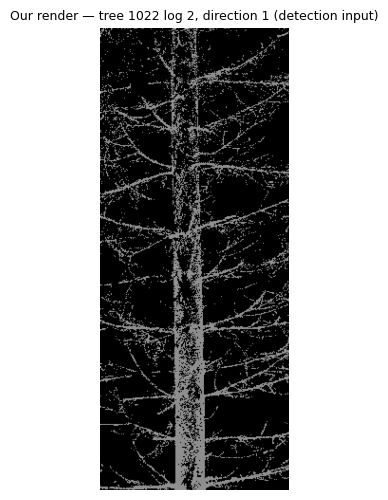

In [ ]:
renders = {}
for _, row in logs.iterrows():
    log_id = int(row["log"])
    n_pts, images = render_log_directions(
        "point_clouds/1022.las", float(row["log_bottom_h"]), float(row["log_top_h"]),
        float(row["tree_X"]), float(row["tree_Y"]),
        out_dir=f"TLSimages/{tree_id}_{log_id}", tree_id=tree_id, log_id=log_id)
    renders[log_id] = images
    print(f"tree {tree_id} log {log_id}: {n_pts:,} points kept; "
          f"image sizes {[im.size for _, im in images]}")

# preview our render of 1022_2 direction 1 (the authors' example partition)
import matplotlib.pyplot as plt
_, im = renders[2][0]
plt.figure(figsize=(3, 6))
plt.imshow(im)
plt.axis("off")
plt.title("Our render — tree 1022 log 2, direction 1 (detection input)", fontsize=9)
plt.show()

## 5. Whorl detection with the authors' pre-trained model

The authors run `yolov5/detect.py --source <TLSimages folder> --weights whorlDetector.pt --save-txt --conf 0.30` (their `whorlDetect-improved.py` lines 121–129). We make the identical call per log with `sys.executable`, plus `--exist-ok` so re-runs overwrite the same `run` folder instead of creating `run2`. The normalized YOLO label files land in `TLSimages/<tree>_<log>/detections/run/labels/`. CPU inference takes a few seconds per image (the checkpoint is a 165 MB YOLOv5x model).

**日本語:** 著者と同じ `detect.py --save-txt --conf 0.30` を各区間に実行します（再実行でフォルダが増えないよう `--exist-ok` のみ追加）。CPU でも 1 枚あたり数秒です。

In [ ]:
import subprocess, sys, shutil

for log_id in sorted(renders):
    src = f"TLSimages/{tree_id}_{log_id}"
    detections = f"{src}/detections"
    shutil.rmtree(detections, ignore_errors=True)  # deterministic re-runs
    print(f"Detecting whorls for tree {tree_id} log {log_id} ...")
    result = subprocess.run(
        [sys.executable, "yolov5/detect.py", "--source", src,
         "--weights", "whorlDetector.pt", "--project", detections,
         "--name", "run", "--save-txt", "--conf", "0.30", "--exist-ok"],
        check=True, capture_output=True, text=True)
    print("\n".join(result.stdout.strip().splitlines()[-2:]))
print("Detection finished for all logs.")

Detecting whorls for tree 1022 log 2 ...


Results saved to TLSimages/1022_2/detections/run
4 labels saved to TLSimages/1022_2/detections/run/labels
Detection finished for all logs.


## 6. From detections to whorl counts and `whorls.csv`

Exactly the authors' post-processing (`whorlDetect-improved.py` lines 134–170): each YOLO label's vertical center `y` (normalized, top-down) is mapped back to stem height by `z = (1 − y) · logLength + logBottomHeight`; detections from all four directions are merged, sorted, and **linearly clustered** by splitting wherever consecutive heights differ by more than `0.09` m (the paper's 9 cm threshold; the variable is named `linearClusteringTreshold` "(cm)" in the authors' code but operates in metres); `whorl_count` is the cluster count and `mean_whorl_distance` is the mean of consecutive cluster spacing × 100 (cm). `−1` marks logs with fewer than two whorls. Results are saved to `whorls.csv`, like the authors' pipeline.

**日本語:** 著者のコードどおり、ラベルの y 中心を `(1−y)·logLength + logBottomHeight` で標高へ戻し、4 方向の検出を 0.09 m 閾値で線形クラスタリングし、節数と平均節間隔(cm)を `whorls.csv` に保存します。

In [ ]:
from statistics import mean
import glob

linearClusteringTreshold = 0.09  # m; the paper's 9 cm clustering threshold (authors' variable, operates in metres)

rows = []
for _, row in logs.iterrows():
    log_id = int(row["log"])
    log_length = float(row["log_top_h"]) - float(row["log_bottom_h"])
    bottom = float(row["log_bottom_h"])
    label_files = sorted(glob.glob(f"TLSimages/{tree_id}_{log_id}/detections/run/labels/*.txt"))
    whorls = []
    for lf in label_files:
        det = pd.read_csv(lf, sep=" ", engine="python", header=None)
        whorls += ((1 - det[2]) * log_length + bottom).tolist()  # authors' denormalization
    if len(whorls) > 1:  # authors' linear clustering, verbatim logic
        whorls.sort()
        arr = np.array(whorls)
        clusters = pd.DataFrame({
            "numbers": whorls,
            "segment": np.cumsum([0] + list(1 * (arr[1:] - arr[:-1] > linearClusteringTreshold))) + 1
        }).groupby("segment").agg({"numbers": set}).to_dict()["numbers"]
        whorls = sorted(mean(clusters[k + 1]) for k in range(len(clusters)))
    whorl_count = len(whorls)
    if len(whorls) > 1:
        mean_whorl_distance = mean([whorls[i + 1] - whorls[i] for i in range(len(whorls) - 1)]) * 100
    else:
        mean_whorl_distance = -1  # authors' sentinel for <2 whorls
    rows.append([tree_id, log_id, whorl_count, round(mean_whorl_distance, 2)])

whorl_df = pd.DataFrame(rows, columns=["tree", "log", "whorl_count", "mean_whorl_distance"])
whorl_df.to_csv("whorls.csv", index=False)
print("whorls.csv written (same output contract as the authors' pipeline):")
print(whorl_df.to_string(index=False))

whorls.csv written (same output contract as the authors' pipeline):
 tree  log  whorl_count  mean_whorl_distance
 1022    2           14                32.56


## 7. Comparison with the authors' shipped example (tree 1022, log 2)

The repository ships the authors' own render and detection output for tree 1022 log 2 (`TLSimages/1022_2/`, `detections/run/`). The figure below shows, for direction 1: **left** — our detection input with our predictions drawn (red boxes, from our run's YOLO labels); **right** — the authors' shipped example output (their model run on their OpenGL render). Whorl heights from both label sets are compared numerically per direction. Agreement here is a plausibility check of the adapted rendering, not a verification of the paper's published accuracies.

**日本語:** 著者が同梱する例（tree 1022, log 2）と本実行を比較します。左＝本実行の入力と予測（赤枠）、右＝著者の同梱検出画像。数値の一致確認は適応描画の妥当性確認であり、論文の公表精度の検証ではありません。

Per-direction whorl detection summary, our run vs the authors' shipped labels:
 direction  our_n  authors_n  min_abs_height_diff_m  our_mean_z_m  authors_mean_z_m
         1     14         15                  0.004          5.99              6.24
         2     18         13                  0.001          5.72              5.76
         3     12         13                  0.002          5.76              6.06
         4     13         20                  0.000          5.87              6.33


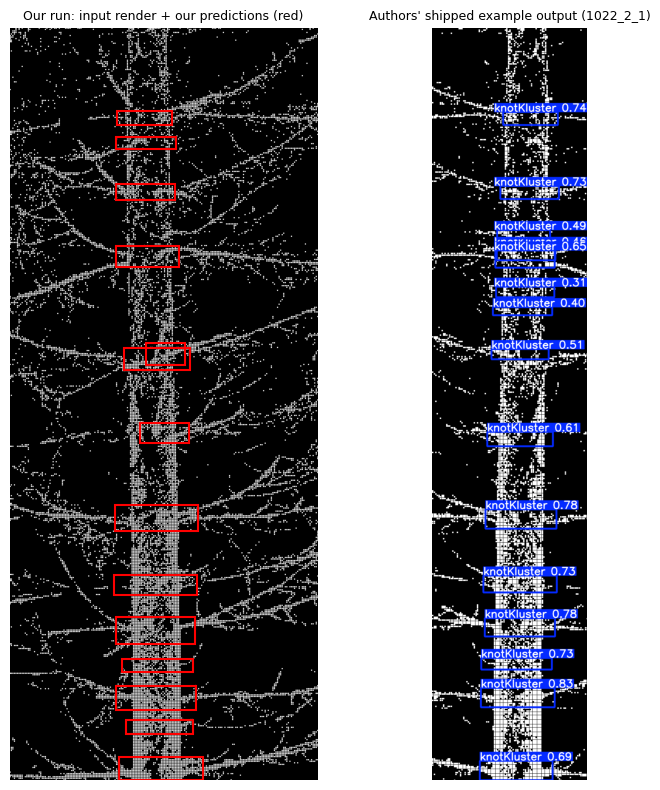

In [ ]:
def read_whorl_heights(label_path, log_length, bottom):
    det = pd.read_csv(label_path, sep=" ", engine="python", header=None)
    return ((1 - det[2]) * log_length + bottom).tolist()

log2 = logs[logs["log"] == 2].iloc[0]
log_length = float(log2["log_top_h"]) - float(log2["log_bottom_h"])
bottom = float(log2["log_bottom_h"])

print("Per-direction whorl detection summary, our run vs the authors' shipped labels:")
comparison = []
for d in range(1, 5):
    ours = read_whorl_heights(f"TLSimages/{tree_id}_2/detections/run/labels/1022_2_{d}.txt",
                              log_length, bottom)
    ref = read_whorl_heights(f"reference/1022_2_{d}.txt", log_length, bottom)
    min_diff = min(abs(a - b) for a in ours for b in ref) if ours and ref else None
    comparison.append([d, len(ours), len(ref),
                       round(min_diff, 3) if min_diff is not None else None,
                       round(float(np.mean(ours)), 2) if ours else None,
                       round(float(np.mean(ref)), 2) if ref else None])
comp_df = pd.DataFrame(comparison, columns=["direction", "our_n", "authors_n",
                                            "min_abs_height_diff_m", "our_mean_z_m", "authors_mean_z_m"])
print(comp_df.to_string(index=False))

# figure: our input render + our predictions | the authors' shipped example output
from PIL import Image
our_im = Image.open("TLSimages/1022_2/1022_2_1.png")
W, H = our_im.size
fig, ax = plt.subplots(1, 2, figsize=(8, 8))
ax[0].imshow(our_im)
lbl = pd.read_csv(f"TLSimages/{tree_id}_2/detections/run/labels/1022_2_1.txt",
                  sep=" ", engine="python", header=None)
for _, r in lbl.iterrows():
    cx, cy, w, h = r[1] * W, r[2] * H, r[3] * W, r[4] * H
    ax[0].add_patch(plt.Rectangle((cx - w / 2, cy - h / 2), w, h,
                                  fill=False, edgecolor="red", linewidth=1.5))
ax[0].set_title("Our run: input render + our predictions (red)", fontsize=9)
ax[0].axis("off")
ref_im = Image.open("reference/1022_2_1.png")
ax[1].imshow(ref_im)
ax[1].set_title("Authors' shipped example output (1022_2_1)", fontsize=9)
ax[1].axis("off")
plt.tight_layout()
plt.savefig("comparison_1022_2.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Interpretation, limitations, and validation record

- **What was executed:** the authors' documented whorl-detector inference pipeline on one example tree (all listed sawlog partitions of tree 1022): crop → four-direction render → YOLOv5x `whorlDetector.pt` detection at confidence 0.30 → cross-direction linear clustering (0.09 m) → per-log `whorl_count` and `mean_whorl_distance` (cm) in `whorls.csv`. All outputs above are from this run.
- **Adaptation:** rendering is re-implemented (numpy square-point rasterization) because Open3D's OpenGL visualizer cannot run headless; the detector call and all post-processing formulas are the authors', verbatim. The comparison in §7 checks the adaptation against the authors' own example for the same partition.
- **Not reproduced / out of scope:** detector training (506 manually annotated stem sections; 3240 whole-tree images), the sawlog detector (not shipped in the repository), and the 479-tree / sawmill X-ray evaluation (data available from the authors on request only). A single-tree run does not verify the paper's reported accuracies (e.g. whorl-count RMSE 7.73 vs X-ray reference).
- **Provenance:** paper doi:10.1093/forestry/cpaf006; author repository `MikaPehkonenHelsinki/Sawlog-branch-whorl-detector` @ `db6ded8d8ebae78859b21441ec25f1d69d793b38` (no LICENSE file in the repository); yolov5 @ `f9578796b8a64889aa9e66dc06914d19f40d338e`; model sha256 `f659f6c8…`. Attribution rests on first-authorship and matching pipeline content — the paper text does not link the repository (the authors state methodologies will be made public).
- **実行内容の要約（日本語）:** tree 1022 の各区間について、著者の推論パイプライン（切り出し→4 方向描画→YOLOv5x 検出→0.09 m クラスタリング→`whorls.csv`）を実行しました。描画のみ適応実装で、それ以外は著者コードの通りです。学習・丸太検出・479 本評価は対象外です。